## Imports

In [1]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt


## Configuration 

In [2]:

ARK_CSV = "C:/Users/Thinkpad/Desktop/etudes/S2/réseau de neurones/Projet/30/arkansas_final.csv"
CAL_CSV = "c:/Users/Thinkpad/Desktop/etudes/S2/réseau de neurones/Projet/30/California_10k.csv"
OUT_DIR = "c:/Users/Thinkpad/Desktop/etudes/S2/réseau de neurones/Projet/30/preprocessed"

BANDS   = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
N_TIMES = 36    
N_BANDS = 10    
SCALE   = 10000.0  


IDX = {band: i for i, band in enumerate(BANDS)}


ARK_LABELS = {0: 'Corn', 1: 'Cotton', 2: 'Rice', 3: 'Soybeans', 4: 'Others'}
CAL_LABELS = {0: 'Rice', 1: 'Alfalfa', 2: 'Grapes', 3: 'Almonds', 4: 'Pistachios', 5: 'Others'}


SAMPLES_PER_CLASS = 300   
VAL_RATIO         = 0.2   
RANDOM_SEED       = 42

os.makedirs(OUT_DIR, exist_ok=True)
print('Dossier de sortie :', OUT_DIR)
print('Index des bandes  :', IDX)

Dossier de sortie : c:/Users/Thinkpad/Desktop/etudes/S2/réseau de neurones/Projet/30/preprocessed
Index des bandes  : {'B2': 0, 'B3': 1, 'B4': 2, 'B5': 3, 'B6': 4, 'B7': 5, 'B8': 6, 'B8A': 7, 'B11': 8, 'B12': 9}


## Construction de l'ordre correct des 360 colonnes



In [3]:
def build_spectral_cols():
    """Retourne la liste ordonnée des 360 colonnes dans l'ordre (temps, bande)."""
    cols = []
    for t in range(N_TIMES):
        for band in BANDS:
            col = band if t == 0 else f'{band}_{t}'
            cols.append(col)
    return cols

spectral_cols = build_spectral_cols()

print(f'Nombre de colonnes spectrales : {len(spectral_cols)}')
print(f'Temps 0  : {spectral_cols[:10]}')
print(f'Temps 1  : {spectral_cols[10:20]}')
print(f'Temps 35 : {spectral_cols[-10:]}')

Nombre de colonnes spectrales : 360
Temps 0  : ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
Temps 1  : ['B2_1', 'B3_1', 'B4_1', 'B5_1', 'B6_1', 'B7_1', 'B8_1', 'B8A_1', 'B11_1', 'B12_1']
Temps 35 : ['B2_35', 'B3_35', 'B4_35', 'B5_35', 'B6_35', 'B7_35', 'B8_35', 'B8A_35', 'B11_35', 'B12_35']


Chargement & inspection des CSV

In [5]:
ark_df = pd.read_csv(ARK_CSV)
cal_df = pd.read_csv(CAL_CSV)

for name, df, label_map in [('ARKANSAS', ark_df, ARK_LABELS), ('CALIFORNIA', cal_df, CAL_LABELS)]:
    print( {name} )
    print(f'  Shape : {df.shape}  (lignes × colonnes)')
    print(f'  Distribution des labels :')
    for cls, count in df['label'].value_counts().sort_index().items():
        print(f'    Classe {int(cls)} ({label_map[int(cls)]:12s}) : {count:5d} ({count/len(df)*100:.1f}%)')
    print(f'  NaN dans features    : {df[spectral_cols].isna().sum().sum()}')
    print(f'  Plage valeurs brutes : [{df[spectral_cols].min().min():.0f}, {df[spectral_cols].max().max():.0f}]')
    missing = [c for c in spectral_cols if c not in df.columns]
    print(f'  Colonnes manquantes  : {len(missing)}  {"" if len(missing)==0 else "  ERREUR : "+str(missing[:3])}')
    print()

{'ARKANSAS'}
  Shape : (10000, 363)  (lignes × colonnes)
  Distribution des labels :
    Classe 0 (Corn        ) :  2000 (20.0%)
    Classe 1 (Cotton      ) :  2000 (20.0%)
    Classe 2 (Rice        ) :  2000 (20.0%)
    Classe 3 (Soybeans    ) :  2000 (20.0%)
    Classe 4 (Others      ) :  2000 (20.0%)
  NaN dans features    : 0
  Plage valeurs brutes : [0, 12986]
  Colonnes manquantes  : 0  

{'CALIFORNIA'}
  Shape : (10000, 361)  (lignes × colonnes)
  Distribution des labels :
    Classe 0 (Rice        ) :  3653 (36.5%)
    Classe 1 (Alfalfa     ) :  1288 (12.9%)
    Classe 2 (Grapes      ) :  1580 (15.8%)
    Classe 3 (Almonds     ) :  1054 (10.5%)
    Classe 4 (Pistachios  ) :   751 (7.5%)
    Classe 5 (Others      ) :  1674 (16.7%)
  NaN dans features    : 0
  Plage valeurs brutes : [0, 9200]
  Colonnes manquantes  : 0  



##  Extraction brute des features 



In [7]:
def extract_raw(df):
    X = df[spectral_cols].values.astype(np.float32)       
    X = X.reshape(len(X), N_TIMES, N_BANDS)                
    X = X.transpose(0, 2, 1)                               
    return X

ark_raw = extract_raw(ark_df)
cal_raw = extract_raw(cal_df)

print('Raw Arkansas  :', ark_raw.shape, '  Min:', ark_raw.min(), '  Max:', ark_raw.max())
print('Raw California:', cal_raw.shape, '  Min:', cal_raw.min(), '  Max:', cal_raw.max())

Raw Arkansas  : (10000, 10, 36)   Min: 0.0   Max: 12986.0
Raw California: (10000, 10, 36)   Min: 0.0   Max: 9200.0


 ## Construction de Input 2 : masque des valeurs manquantes



In [8]:
def build_mask(X_raw):

   
    all_zero = (X_raw == 0).all(axis=1)       
    mask = (~all_zero).astype(np.float32)      
    return mask

ark_mask = build_mask(ark_raw)
cal_mask = build_mask(cal_raw)

for name, mask in [('Arkansas', ark_mask), ('California', cal_mask)]:
    miss_rate   = (mask == 0).mean() * 100
    miss_per_px = (mask == 0).sum(axis=1)
    print( {name} )
    print(f'  Shape masque             : {mask.shape}')
    print(f'  Taux global manquants    : {miss_rate:.2f}%')
    print(f'  Pixels avec 0 manquant   : {(miss_per_px == 0).sum():5d} ({(miss_per_px==0).mean()*100:.1f}%)')
    print(f'  Pixels avec 1-5 manq.    : {((miss_per_px>=1)&(miss_per_px<=5)).sum():5d}')
    print(f'  Pixels avec >10 manq.    : {(miss_per_px>10).sum():5d}')
    print(f'  Valeurs uniques          : {np.unique(mask)}  (doit être [0. 1.])')
    print()

{'Arkansas'}
  Shape masque             : (10000, 36)
  Taux global manquants    : 22.71%
  Pixels avec 0 manquant   :     0 (0.0%)
  Pixels avec 1-5 manq.    :   168
  Pixels avec >10 manq.    :  1285
  Valeurs uniques          : [0. 1.]  (doit être [0. 1.])

{'California'}
  Shape masque             : (10000, 36)
  Taux global manquants    : 16.13%
  Pixels avec 0 manquant   :     4 (0.0%)
  Pixels avec 1-5 manq.    :  5132
  Pixels avec >10 manq.    :    60
  Valeurs uniques          : [0. 1.]  (doit être [0. 1.])



## Normalisation 



In [9]:
def normalize(X_raw):
   
    return (X_raw / SCALE).astype(np.float32)

ark_input1 = normalize(ark_raw)
cal_input1 = normalize(cal_raw)

for name, X in [('Arkansas', ark_input1), ('California', cal_input1)]:
    print( {name} )
    print(f'  Shape  : {X.shape}   dtype : {X.dtype}')
    print(f'  Min    : {X.min():.4f}')
    print(f'  Max    : {X.max():.4f}  (légèrement > 1.0 possible, normal)')
    print(f'  Les 0 correspondent aux valeurs manquantes : OK')
    print()

{'Arkansas'}
  Shape  : (10000, 10, 36)   dtype : float32
  Min    : 0.0000
  Max    : 1.2986  (légèrement > 1.0 possible, normal)
  Les 0 correspondent aux valeurs manquantes : OK

{'California'}
  Shape  : (10000, 10, 36)   dtype : float32
  Min    : 0.0000
  Max    : 0.9200  (légèrement > 1.0 possible, normal)
  Les 0 correspondent aux valeurs manquantes : OK



##  Extraction des Labels

In [11]:
ark_labels = ark_df['label'].values.astype(np.int64)
cal_labels = cal_df['label'].values.astype(np.int64)

print(' LABELS ARKANSAS ')
print(f'  Shape : {ark_labels.shape}  |  dtype : {ark_labels.dtype}')
for cls, name in ARK_LABELS.items():
    n = (ark_labels == cls).sum()
    print(f'  Classe {cls} ({name:10s}) : {n:5d} ({n/len(ark_labels)*100:.1f}%)')

print()
print(' LABELS CALIFORNIA ')
print(f'  Shape : {cal_labels.shape}  |  dtype : {cal_labels.dtype}')
for cls, name in CAL_LABELS.items():
    n = (cal_labels == cls).sum()
    print(f'  Classe {cls} ({name:12s}) : {n:5d} ({n/len(cal_labels)*100:.1f}%)')

 LABELS ARKANSAS 
  Shape : (10000,)  |  dtype : int64
  Classe 0 (Corn      ) :  2000 (20.0%)
  Classe 1 (Cotton    ) :  2000 (20.0%)
  Classe 2 (Rice      ) :  2000 (20.0%)
  Classe 3 (Soybeans  ) :  2000 (20.0%)
  Classe 4 (Others    ) :  2000 (20.0%)

 LABELS CALIFORNIA 
  Shape : (10000,)  |  dtype : int64
  Classe 0 (Rice        ) :  3653 (36.5%)
  Classe 1 (Alfalfa     ) :  1288 (12.9%)
  Classe 2 (Grapes      ) :  1580 (15.8%)
  Classe 3 (Almonds     ) :  1054 (10.5%)
  Classe 4 (Pistachios  ) :   751 (7.5%)
  Classe 5 (Others      ) :  1674 (16.7%)


##  Vérification d'intégrité

In [13]:
def check_integrity(input1, input2, labels, label_map, name):
    errors, warnings_list = [], []
    N = len(labels)

    
    if input1.shape != (N, N_BANDS, N_TIMES):
        errors.append(f'Input1 shape {input1.shape} ≠ attendu ({N}, {N_BANDS}, {N_TIMES})')
    if input2.shape != (N, N_TIMES):
        errors.append(f'Input2 shape {input2.shape} ≠ attendu ({N}, {N_TIMES})')
    if np.isnan(input1).any():
        errors.append(f'Input1 contient des NaN : {np.isnan(input1).sum()}')
    if np.isinf(input1).any():
        errors.append(f'Input1 contient des Inf : {np.isinf(input1).sum()}')
    if set(np.unique(input2)) - {0.0, 1.0}:
        errors.append(f'Input2 valeurs hors [0,1] : {np.unique(input2)}')
    if not set(np.unique(labels)).issubset(set(label_map.keys())):
        errors.append(f'Labels classes inconnues : {np.unique(labels)}')

    
  
    missing_2d = (input2 == 0)                                   
    missing_3d = np.broadcast_to(
        missing_2d[:, np.newaxis, :], input1.shape              
    )
    masked_vals = input1[missing_3d]
    n_nonzero = (masked_vals != 0).sum()
    if n_nonzero > 0:
        warnings_list.append(f'{n_nonzero} valeurs non-nulles aux positions masquées')

    print( {name} )
    if errors:
        for e in errors: print(f'   {e}')
    else:
        print(f'   Aucune erreur')
    if warnings_list:
        for w in warnings_list: print(f'   {w}')
    print(f'  Input1 : {input1.shape}  min={input1.min():.4f}  max={input1.max():.4f}')
    print(f'  Input2 : {input2.shape}  taux manquants={(input2==0).mean()*100:.2f}%')
    print(f'  Labels : {labels.shape}  classes={sorted(np.unique(labels).tolist())}')
    print()

check_integrity(ark_input1, ark_mask, ark_labels, ARK_LABELS, 'ARKANSAS')
check_integrity(cal_input1, cal_mask, cal_labels, CAL_LABELS, 'CALIFORNIA')

{'ARKANSAS'}
   Aucune erreur
  Input1 : (10000, 10, 36)  min=0.0000  max=1.2986
  Input2 : (10000, 36)  taux manquants=22.71%
  Labels : (10000,)  classes=[0, 1, 2, 3, 4]

{'CALIFORNIA'}
   Aucune erreur
  Input1 : (10000, 10, 36)  min=0.0000  max=0.9200
  Input2 : (10000, 36)  taux manquants=16.13%
  Labels : (10000,)  classes=[0, 1, 2, 3, 4, 5]



## C Split train / validation / test  




In [15]:
from sklearn.model_selection import train_test_split

def split_dataset(input1, input2, labels, label_map,
                  n_per_class=SAMPLES_PER_CLASS,
                  val_ratio=VAL_RATIO,
                  seed=RANDOM_SEED):
    
    np.random.seed(seed)
    train_idx, val_idx, test_idx = [], [], []

    for cls in sorted(label_map.keys()):
        idx_cls = np.where(labels == cls)[0]  

        
        n_available = len(idx_cls)
        n_use = min(n_per_class, n_available)

        
        np.random.shuffle(idx_cls)
        idx_trainval = idx_cls[:n_use]
        idx_test     = idx_cls[n_use:]

     
        idx_train, idx_val = train_test_split(
            idx_trainval, test_size=val_ratio, random_state=seed
        )

        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)


    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    def subset(idx):
        return {
            'input1': input1[idx],
            'input2': input2[idx],
            'labels': labels[idx]
        }

    return subset(train_idx), subset(val_idx), subset(test_idx)



ark_train, ark_val, ark_test = split_dataset(
    ark_input1, ark_mask, ark_labels, ARK_LABELS
)


cal_train, cal_val, cal_test = split_dataset(
    cal_input1, cal_mask, cal_labels, CAL_LABELS
)


for name, train, val, test, label_map in [
    ('ARKANSAS',   ark_train, ark_val, ark_test, ARK_LABELS),
    ('CALIFORNIA', cal_train, cal_val, cal_test, CAL_LABELS)
]:
    print( {name} )
    print(f'  Train : {train["input1"].shape}  |  {len(train["labels"])} échantillons')
    print(f'  Val   : {val["input1"].shape}  |  {len(val["labels"])} échantillons')
    print(f'  Test  : {test["input1"].shape}  |  {len(test["labels"])} échantillons')
    print(f'  Total : {len(train["labels"])+len(val["labels"])+len(test["labels"])}')
    print(f'  Distribution train par classe :')
    for cls, cname in label_map.items():
        n = (train['labels'] == cls).sum()
        print(f'    Classe {cls} ({cname:12s}) : {n}')
    print()

{'ARKANSAS'}
  Train : (1200, 10, 36)  |  1200 échantillons
  Val   : (300, 10, 36)  |  300 échantillons
  Test  : (8500, 10, 36)  |  8500 échantillons
  Total : 10000
  Distribution train par classe :
    Classe 0 (Corn        ) : 240
    Classe 1 (Cotton      ) : 240
    Classe 2 (Rice        ) : 240
    Classe 3 (Soybeans    ) : 240
    Classe 4 (Others      ) : 240

{'CALIFORNIA'}
  Train : (1440, 10, 36)  |  1440 échantillons
  Val   : (360, 10, 36)  |  360 échantillons
  Test  : (8200, 10, 36)  |  8200 échantillons
  Total : 10000
  Distribution train par classe :
    Classe 0 (Rice        ) : 240
    Classe 1 (Alfalfa     ) : 240
    Classe 2 (Grapes      ) : 240
    Classe 3 (Almonds     ) : 240
    Classe 4 (Pistachios  ) : 240
    Classe 5 (Others      ) : 240



## Sauvegarde des fichiers .npy

In [21]:
# ---- Arkansas ----
np.save(os.path.join(OUT_DIR, 'Arkansas_input1.npy'), ark_input1)
np.save(os.path.join(OUT_DIR, 'Arkansas_input2.npy'), ark_mask)
np.save(os.path.join(OUT_DIR, 'Arkansas_labels.npy'), ark_labels)

np.save(os.path.join(OUT_DIR, 'Arkansas_train_input1.npy'), ark_train['input1'])
np.save(os.path.join(OUT_DIR, 'Arkansas_train_input2.npy'), ark_train['input2'])
np.save(os.path.join(OUT_DIR, 'Arkansas_train_labels.npy'), ark_train['labels'])
np.save(os.path.join(OUT_DIR, 'Arkansas_val_input1.npy'),   ark_val['input1'])
np.save(os.path.join(OUT_DIR, 'Arkansas_val_input2.npy'),   ark_val['input2'])
np.save(os.path.join(OUT_DIR, 'Arkansas_val_labels.npy'),   ark_val['labels'])
np.save(os.path.join(OUT_DIR, 'Arkansas_test_input1.npy'),  ark_test['input1'])
np.save(os.path.join(OUT_DIR, 'Arkansas_test_input2.npy'),  ark_test['input2'])
np.save(os.path.join(OUT_DIR, 'Arkansas_test_labels.npy'),  ark_test['labels'])

# ---- California ----
np.save(os.path.join(OUT_DIR, 'California_input1.npy'), cal_input1)
np.save(os.path.join(OUT_DIR, 'California_input2.npy'), cal_mask)
np.save(os.path.join(OUT_DIR, 'California_labels.npy'), cal_labels)

np.save(os.path.join(OUT_DIR, 'California_train_input1.npy'), cal_train['input1'])
np.save(os.path.join(OUT_DIR, 'California_train_input2.npy'), cal_train['input2'])
np.save(os.path.join(OUT_DIR, 'California_train_labels.npy'), cal_train['labels'])
np.save(os.path.join(OUT_DIR, 'California_val_input1.npy'),   cal_val['input1'])
np.save(os.path.join(OUT_DIR, 'California_val_input2.npy'),   cal_val['input2'])
np.save(os.path.join(OUT_DIR, 'California_val_labels.npy'),   cal_val['labels'])
np.save(os.path.join(OUT_DIR, 'California_test_input1.npy'),  cal_test['input1'])
np.save(os.path.join(OUT_DIR, 'California_test_input2.npy'),  cal_test['input2'])
np.save(os.path.join(OUT_DIR, 'California_test_labels.npy'),  cal_test['labels'])

print('Fichiers sauvegardés dans :', OUT_DIR)
print()
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f'  {f:45s}  {size:8.1f} Ko')

Fichiers sauvegardés dans : c:/Users/Thinkpad/Desktop/etudes/S2/réseau de neurones/Projet/30 3/preprocessed

  Arkansas_input1.npy                             14062.6 Ko
  Arkansas_input2.npy                              1406.4 Ko
  Arkansas_labels.npy                                78.2 Ko
  Arkansas_test_input1.npy                        11953.2 Ko
  Arkansas_test_input2.npy                         1195.4 Ko
  Arkansas_test_labels.npy                           66.5 Ko
  Arkansas_train_input1.npy                        1687.6 Ko
  Arkansas_train_input2.npy                         168.9 Ko
  Arkansas_train_labels.npy                           9.5 Ko
  Arkansas_val_input1.npy                           422.0 Ko
  Arkansas_val_input2.npy                            42.3 Ko
  Arkansas_val_labels.npy                             2.5 Ko
  California_input1.npy                           14062.6 Ko
  California_input2.npy                            1406.4 Ko
  California_labels.npy              

##  Vérification finale (rechargement)

In [18]:

print('  VÉRIFICATION FINALE — RECHARGEMENT DES FICHIERS')


for region, label_map in [('Arkansas', ARK_LABELS), ('California', CAL_LABELS)]:
    X  = np.load(os.path.join(OUT_DIR, f'{region}_input1.npy'))
    M  = np.load(os.path.join(OUT_DIR, f'{region}_input2.npy'))
    y  = np.load(os.path.join(OUT_DIR, f'{region}_labels.npy'))
    Xtr = np.load(os.path.join(OUT_DIR, f'{region}_train_input1.npy'))
    Xv  = np.load(os.path.join(OUT_DIR, f'{region}_val_input1.npy'))
    Xte = np.load(os.path.join(OUT_DIR, f'{region}_test_input1.npy'))

    print(f'\n  {region.upper()}')
    print(f'  Input1 complet : {X.shape}  min={X.min():.4f}  max={X.max():.4f}')
    print(f'  Input2 complet : {M.shape}  valeurs={np.unique(M)}')
    print(f'  Labels complet : {y.shape}  classes={sorted(np.unique(y).tolist())}')
    print(f'  Train  : {Xtr.shape}')
    print(f'  Val    : {Xv.shape}')
    print(f'  Test   : {Xte.shape}')
    print(f'  Total  : {len(Xtr)+len(Xv)+len(Xte)} (doit = {len(y)})')



  VÉRIFICATION FINALE — RECHARGEMENT DES FICHIERS

  ARKANSAS
  Input1 complet : (10000, 10, 36)  min=0.0000  max=1.2986
  Input2 complet : (10000, 36)  valeurs=[0. 1.]
  Labels complet : (10000,)  classes=[0, 1, 2, 3, 4]
  Train  : (1200, 10, 36)
  Val    : (300, 10, 36)
  Test   : (8500, 10, 36)
  Total  : 10000 (doit = 10000)

  CALIFORNIA
  Input1 complet : (10000, 10, 36)  min=0.0000  max=0.9200
  Input2 complet : (10000, 36)  valeurs=[0. 1.]
  Labels complet : (10000,)  classes=[0, 1, 2, 3, 4, 5]
  Train  : (1440, 10, 36)
  Val    : (360, 10, 36)
  Test   : (8200, 10, 36)
  Total  : 10000 (doit = 10000)


## Visualisations


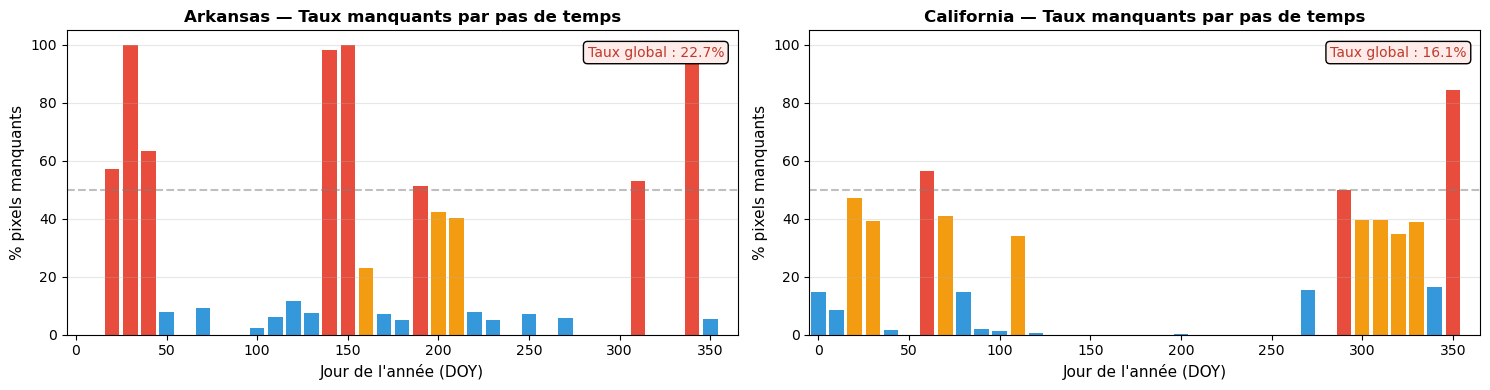

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, M_data, title in zip(axes, [ark_mask, cal_mask], ['Arkansas', 'California']):
    miss_pct = (M_data == 0).mean(axis=0) * 100
    days = [t * 10 for t in range(N_TIMES)]
    colors = ['#E74C3C' if v > 50 else '#F39C12' if v > 20 else '#3498DB' for v in miss_pct]
    ax.bar(days, miss_pct, width=8, color=colors)
    ax.set_xlabel('Jour de l\'année (DOY)', fontsize=11)
    ax.set_ylabel('% pixels manquants', fontsize=11)
    ax.set_title(f'{title} — Taux manquants par pas de temps', fontsize=12, fontweight='bold')
    ax.set_xlim(-5, 365)
    ax.set_ylim(0, 105)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    taux = (M_data == 0).mean() * 100
    ax.text(0.98, 0.95, f'Taux global : {taux:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, color='#C0392B',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDECEA'))

plt.tight_layout()
plt.savefig('missing_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## NDVI 


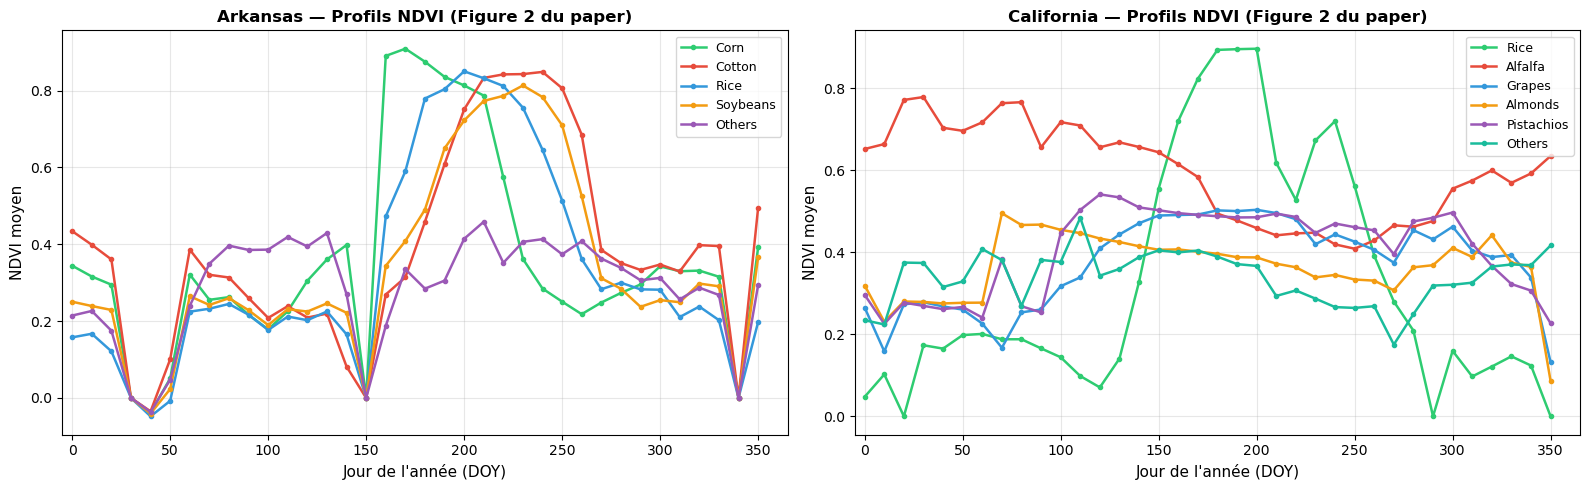

⚠️  Ces indices sont pour la visualisation uniquement — pas des features du modèle


In [ ]:
def compute_ndvi(X_raw, mask):
    
    eps = 1e-8
  
    NIR  = X_raw[:, IDX['B8'], :]   
    Red  = X_raw[:, IDX['B4'], :]   
    ndvi = (NIR - Red) / (NIR + Red + eps)
    return ndvi * mask               

ark_ndvi = compute_ndvi(ark_raw, ark_mask)
cal_ndvi = compute_ndvi(cal_raw, cal_mask)

COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
days   = np.array([t * 10 for t in range(N_TIMES)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, ndvi_data, labels_data, label_map, title in [
    (axes[0], ark_ndvi, ark_labels, ARK_LABELS, 'Arkansas'),
    (axes[1], cal_ndvi, cal_labels, CAL_LABELS, 'California')
]:
    for cls_id, cls_name in label_map.items():
        cls_mask = (labels_data == cls_id)
        if cls_mask.sum() < 10:
            continue
        cls_ndvi = ndvi_data[cls_mask]       
        
        valid_sum   = cls_ndvi.sum(axis=0)   
        valid_count = (cls_ndvi != 0).sum(axis=0) + 1e-8
        mean_ndvi   = valid_sum / valid_count
        ax.plot(days, mean_ndvi, label=cls_name,
                color=COLORS[cls_id % len(COLORS)],
                marker='o', markersize=3, linewidth=1.8)
    ax.set_xlabel('Jour de l\'année (DOY)', fontsize=11)
    ax.set_ylabel('NDVI moyen', fontsize=11)
    ax.set_title(f'{title} — Profils NDVI (Figure 2 du paper)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(-5, 365)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ndvi_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Ces indices sont pour la visualisation uniquement — pas des features du modèle')

###  Distribution des bandes normalisées 

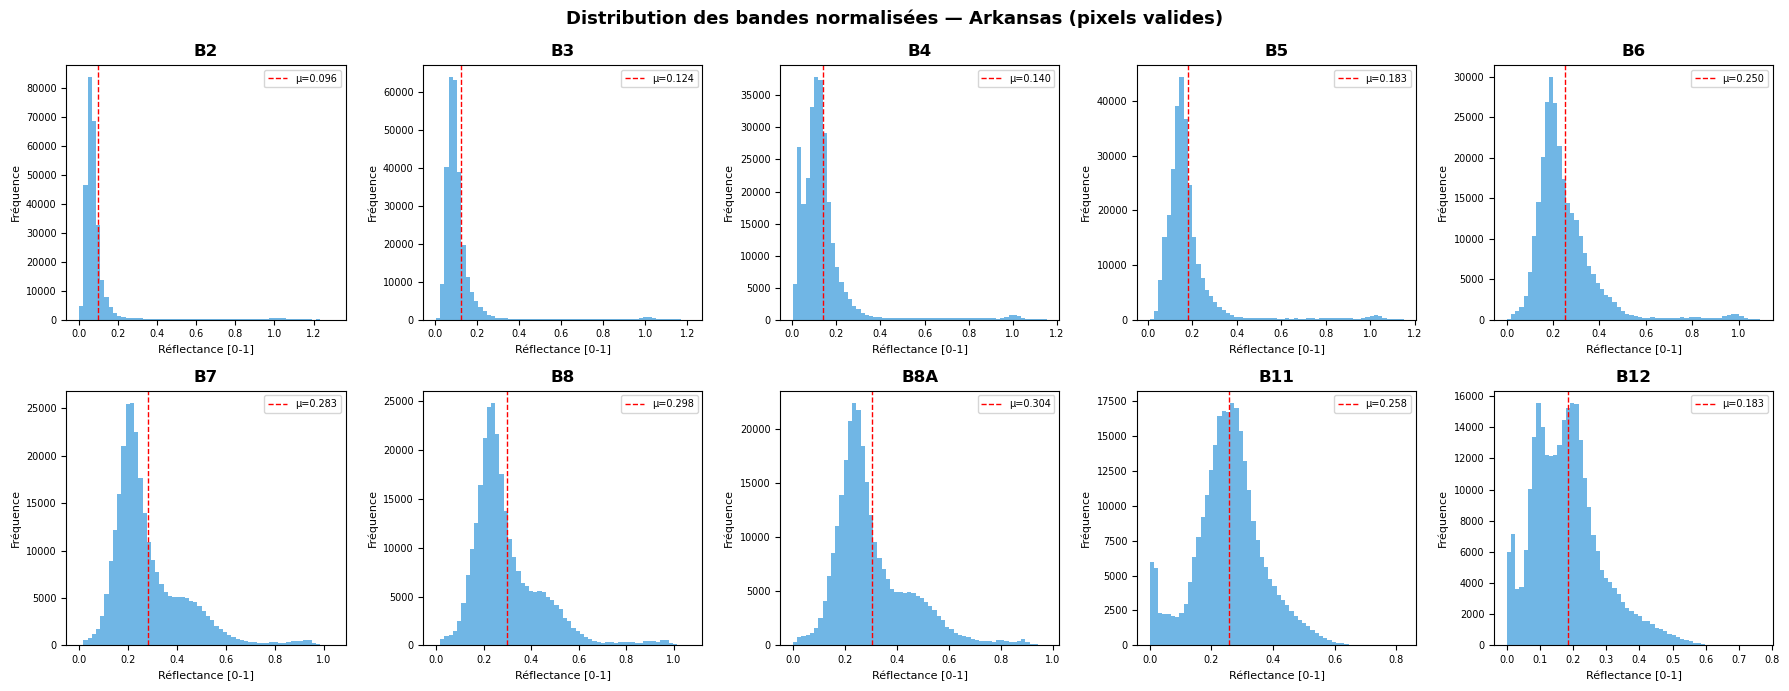

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Distribution des bandes normalisées — Arkansas (pixels valides)', fontsize=13, fontweight='bold')

for i, (band_name, ax) in enumerate(zip(BANDS, axes.flatten())):
    
    band_data    = ark_input1[:, i, :]         
    valid_pixels = band_data[ark_mask == 1]    

    ax.hist(valid_pixels, bins=60, color='#3498DB', alpha=0.7, edgecolor='none')
    ax.set_title(f'{band_name}', fontweight='bold')
    ax.set_xlabel('Réflectance [0-1]', fontsize=8)
    ax.set_ylabel('Fréquence', fontsize=8)
    mean_v = valid_pixels.mean()
    ax.axvline(mean_v, color='red', linestyle='--', linewidth=1, label=f'μ={mean_v:.3f}')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('band_distributions.png', dpi=150, bbox_inches='tight')
plt.show()